## Hw 1b: Training a Linear Classifier on Fashion-MNIST

In this part of the assignment, you'll build and train a simple image classifier using PyTorch. You'll use the Fashion-MNIST dataset, which contains grayscale images of clothing items (e.g., t-shirts, sneakers, coats). Your goal is to train a linear model (or shallow neural network) to correctly classify each image into one of the 10 categories.

This assignment will help you practice:

- Loading and visualizing image data

- Building models with torch.nn

- Implementing training and evaluation loops

- Measuring model performance

By the end, you’ll understand the basics of supervised learning with images using PyTorch.
https://www.kaggle.com/datasets/zalando-research/fashionmnist

In [1]:
# import pytorch libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

### Download the data
Got here and download the data https://www.kaggle.com/datasets/zalando-research/fashionmnist

I made a directory `fashion_mnist` and unziped the file inside that directory. Here is what I have:

In [2]:
! ls fashion_mnist

fashion-mnist_test.csv  fashion-mnist_train.csv


In [3]:
# train csv file
train_df = pd.read_csv("fashion_mnist/fashion-mnist_train.csv")
test_df = pd.read_csv("fashion_mnist/fashion-mnist_test.csv")

# each row is an observation, each column is a pixel value
train_df.shape, test_df.shape

((60000, 785), (10000, 785))

In [4]:
# the first element is the label
train_df.head(2)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,119,114,130,76,0,0,0,0,0,0


In [5]:
# Split labels and pixel data
labels_np = train_df.iloc[:, 0].astype(np.int64).values.copy()
images_np = train_df.iloc[:, 1:].astype(np.float32).values.copy()

test_labels_np = test_df.iloc[:, 0].astype(np.int64).values.copy()
test_images_np = test_df.iloc[:, 1:].astype(np.float32).values.copy()

In [6]:
ims = images_np[0:8].reshape(-1, 28, 28)
ims.shape

(8, 28, 28)

In [7]:
class_names = [
    "T-shirt/top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle boot"    # 9
]

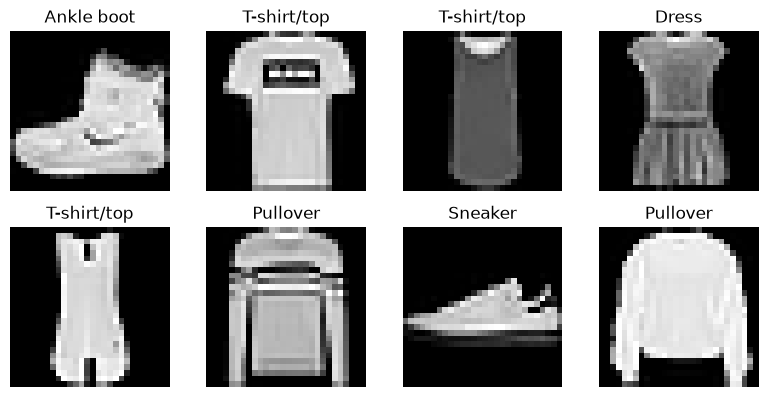

In [8]:
N = 8 # number of images to visualize
# visualize one image
imgs = images_np[0:N].reshape(-1, 28, 28)
def show_batch(images, labels):
    plt.figure(figsize=(8, 8))
    for i in range(N):
        img = images[i]
        label = class_names[labels[i]]
        plt.subplot(4, 4, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(imgs, labels_np[:N])

### Transform numpy to torch tensors
Define `X_train`, `Y_train`, `X_test` and `Y_test` your torch tensors from numpy arrays using `torch.tensor`.

In [9]:
X_train = torch.tensor(images_np, dtype=torch.float32) / 255.0
Y_train = torch.tensor(labels_np, dtype=torch.long)
X_test = torch.tensor(test_images_np, dtype=torch.float32) / 255.0
Y_test = torch.tensor(test_labels_np, dtype=torch.long)

In [10]:
X_train.shape

torch.Size([60000, 784])

### Create a model
Create a linear model or a shalow neural network that can fit this data.

In [11]:
# a linear model is just a single fully-connected layer
model = nn.Linear(X_train.shape[1], 10)

In [12]:
# check that your model run on your data
logit = model(X_train)
logit.shape

torch.Size([60000, 10])

### Compute the training loss 
Choose an appropriate loss function and compute the loss of the untrained model on the training data.

Useful url: https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html

In [13]:
loss = F.cross_entropy(logit, Y_train)
loss

tensor(2.3855, grad_fn=<NllLossBackward0>)

### Compute accuracy 
First, compute a **hard prediction**: given a prediction vector containing class probabilities, select the class with the highest probability. This gives you the predicted class label. Then, compare these predicted labels to the true labels to compute the accuracy of the untrained (random) model.

Useful url: https://docs.pytorch.org/docs/stable/generated/torch.argmax.html

In [14]:
y_pred_class = torch.argmax(logit, dim=1)
accuracy = (y_pred_class == Y_train).float().mean()
accuracy

tensor(0.0990)

In [15]:
y_pred_class.shape

torch.Size([60000])

In [16]:
y_pred_class[:10]

tensor([1, 3, 3, 3, 3, 7, 1, 7, 3, 3])

### Train your model
Pay attention to the training loss: if it oscillates or fails to decrease steadily, your learning rate may be too high. One strategy is to start with a higher learning rate for a few iterations to accelerate early learning, then reduce it to stabilize training.

Hint: I get 78% test accuracy with a linear model.

In [17]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 200
for epoch in range(epochs):
    logit = model(X_train)
    loss = F.cross_entropy(logit, Y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

### Compute Accuracy of Test data

In [18]:
model.eval()
with torch.no_grad():
    logit_test = model(X_test)
    test_pred_class = torch.argmax(logit_test, dim=1)
    test_accuracy = (test_pred_class == Y_test).float().mean()

print(f"test accuracy: {test_accuracy.item():.4f}")

test accuracy: 0.8425


### Use 2-layer neural.
Try using a 2-layer neural network and aim to achieve the best accuracy you can.

In [19]:
hidden_size = 128
model2 = nn.Sequential(
    nn.Linear(X_train.shape[1], hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, 10),
)

optimizer = optim.Adam(model2.parameters(), lr=0.001)

epochs = 300
for epoch in range(epochs):
    optimizer.zero_grad()
    logit = model2(X_train)
    loss = F.cross_entropy(logit, Y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 30 == 0:
        print(f"epoch {epoch + 1:3d} | train loss {loss.item():.4f}")

model2.eval()
with torch.no_grad():
    logit_test = model2(X_test)
    test_pred_class = torch.argmax(logit_test, dim=1)
    test_accuracy = (test_pred_class == Y_test).float().mean()

print(f"2-layer NN test accuracy: {test_accuracy.item():.4f}")

epoch  30 | train loss 0.7491


epoch  60 | train loss 0.5591


epoch  90 | train loss 0.4849


epoch 120 | train loss 0.4445


epoch 150 | train loss 0.4175


epoch 180 | train loss 0.3960


epoch 210 | train loss 0.3782


epoch 240 | train loss 0.3621


epoch 270 | train loss 0.3480


epoch 300 | train loss 0.3358
2-layer NN test accuracy: 0.8636
